# Strategies to Estimate the Immediate Network Disruption Effects of Aircraft Accidents and Incidents: Evidence from Wildlife-Aircraft Collisions

**Author:** Levi Altringer  
**Date:** 2026-01-29

### Project Overview
This notebook estimates the causal impact of airline strikes on various delay metrics using a **Fixed-Effects OLS** framework. We utilize two primary identification strategies:
1. **Within-Airline Estimator:** Estimates the post-strike impact to the struck carrier relative to own outcomes in the pre-strike period, all else equal.
2. **Cross-Airline Estimator:** Estimates the pre- and post-strike impact to the struck carrier relative to outcomes observed among other airlines, all else equal.

### Data & Methodology
- **Estimation Engine:** `linearmodels.iv.AbsorbingLS` for high-dimensional fixed effects.
- **Frequency:** 4-hour event windows (48 hours pre/post strike).
- **Inference:** Heteroskedasticity-robust standard errors.

In [1]:
#Import required libraries:
import pandas as pd
import numpy as np
from linearmodels.iv import AbsorbingLS
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# Load data:
master_df = pd.read_parquet('data/flight_data.parquet')

In [3]:
# ---- Define outcome variables ---- #
# - Flight departure is delayed 15+ minutes (delay_gt_15)
# - Flight departure is delayed 30+ minutes (delay_gt_15)
# - Flight departure is delayed 60+ minutes (delay_gt_15)
# - Flight departure is delayed 120+ minutes (delay_gt_15)
# - Flight departure delay in minutes (departure_delay_minutes)
for t in [15, 30, 60, 120]:
    # A flight is '1' if it is delayed >= T minutes OR if it was cancelled
    master_df[f'delay_gt_{t}'] = ((master_df['departure_delay_minutes'] >= t)).astype(int)
OUTCOMES = ['delay_gt_15', 'delay_gt_30', 'delay_gt_60', 'delay_gt_120', 'departure_delay_minutes']


# ---- Define treatment variables (event study variable engineering) ----#
# Treatment variables are binaries equal to 1 if the flight is:
#     - (1) is greater than l hours but less than u hours from the effective timing of the srike incident (ETS) and;
#     - (2) operated by the same airline to which the strike occured
# These indicators measure both the treatment status (same as strike airline) and time distance, in four hour intervals, from the ETS.
#    - Negative = Pre-strike (e.g., lead_12 = 1 indicates that the flight is operated by the strike airline and was scheduled to depart [-48 hours,-44 hours) before the ETS)
#    - Positive = Post-strike (e.g., lag_5 = 1 indicates that the flight is operated by the strike airline and was scheduled to depart (16 hours, 20 hours] after the ETS)
master_df['scheduled_departure_datetime'] = pd.to_datetime(master_df['scheduled_departure_datetime'], format='mixed')
master_df['strike_date_time'] = pd.to_datetime(master_df['strike_date_time'], format='mixed')
master_df['hours_from_strike'] = (master_df['scheduled_departure_datetime'] - master_df['strike_date_time']).dt.total_seconds() / 3600
master_df['is_strike_airline'] = (master_df['carrier_code'] == master_df['strike_airline']).astype(int)
# Duplicate variables for steamlined syntax in loops:
h = master_df['hours_from_strike']
is_same = master_df['is_strike_airline'] == 1
# Empty list for the names of the treatment variables:
lag_cols = []
lead_cols = []
# Create leads (Pre-Strike 1-12):
for i in range(1, 13):
    col = f'lead{i}'
    master_df[col] = np.where((h < -(i-1)*4) & (h >= -i*4) & is_same, 1, 0)
    lead_cols.append(col)
# Create lags (Post-Strike 1-12):
for i in range(1, 13):
    col = f'lag{i}'
    master_df[col] = np.where((h > (i-1)*4) & (h <= i*4) & is_same, 1, 0)
    lag_cols.append(col)
# List of treatment variables (Removes "lead_1" as reference group):
WITHIN_TREATMENT = lag_cols
CROSS_TREATMENT = lead_cols[1:] + lag_cols


# ---- Define covariate variables ---- #
# - Total number of flights scheduled to depart in that airport-day-hour (congestion)
# -  (temp)
# -  (visibility)
# -  (windspeed)
# -  (precip)
# -  (humidity)
master_df['hour'] = master_df['scheduled_departure_datetime'].dt.hour
master_df['congestion'] = master_df.groupby(['airport', 'date', 'hour'])['airport'].transform('count')
master_df['congestion_sq'] = master_df['congestion']**2
master_df['temp'] = master_df['temp'] + 25
master_df['temp_sq'] = master_df['temp']**2
master_df['windspeed_sq'] = master_df['windspeed']**2
master_df['windgust_dum'] = np.where(master_df['windgust'].isna(), 0, 1)
master_df['precip_sq'] = master_df['precip']**2
master_df['snow_dum'] = np.where(master_df['snow'] > 0, 1, 0)
master_df['snow_dum'] = master_df['snow_dum'].fillna(0)
COVARIATES = ['congestion', 'congestion_sq', 
              'temp', 'temp_sq', 
              'windspeed', 'windspeed_sq', 'windgust_dum', 
              'precip', 'precip_sq', 'snow_dum']


# ---- Define fixed effect variables  ---- #
# - Airport-by-airline fixed effects, for the flight's operating airline and airport--e.g.,"DEN_UA" (airport_carrier)
# - Fixed effect for the flight's hour of scheduled departure--e.g.,"16:00" (hour)
# - Fixed effect for the flight's year--e.g.,"2018" (year)
# - Fixed effect for the flight's month--e.g.,"January" (month)
# - Fixed effect for the flight's day of the week--e.g.,"Sunday" (day_of_week)
master_df['airport_carrier'] = master_df['airport'].astype(str) + "_" + master_df['carrier_code'].astype(str)
master_df['year'] = master_df['scheduled_departure_datetime'].dt.year
master_df['month'] = master_df['scheduled_departure_datetime'].dt.month
master_df['day_of_week'] = master_df['scheduled_departure_datetime'].dt.dayofweek
FIXED_EFFECTS = ['airport_carrier','hour','year','month','day_of_week']

In [4]:
def run_within_airline_event_study(df, dv):
    """
    Estimates the Within-Airline fixed effects OLS model.
    
    Econometric Strategy:
    --------------------
    This identifies the 'within' effect by comparing post-strike outcomes to 
    within-airline pre-strike outcomes, all else equal. By subsetting to the 
    treated airline, we isolate variation specific to the struck carrier.

    Parameters:
    -----------
    df : pd.DataFrame
        A subset of the master dataset containing flight observations.
    dv : str
        The dependent variable to be analyzed (e.g., 'departure_delay_minutes').

    Returns:
    --------
    results : linearmodels.iv.results.AbsorbingLSResults
        The fitted regression results object.
    """
    
    # Subset to treated airline to isolate the 'within' comparison group
    df_treated = df[df['is_strike_airline'] == 1].copy()
    
    # Organize data into dependent and independent variables
    dependent_var = df_treated[dv].copy().astype(float)
    independent_vars = df_treated[WITHIN_TREATMENT + COVARIATES].copy().fillna(0)

    # Absorb fixed effects (e.g., Airline-Airport or Day-of-Week)
    fixed_effect_vars = df_treated[FIXED_EFFECTS].astype('category')

    print(f"Running \"Within-Airline Estimator\" on {len(df_treated):,} observations...")

    model = AbsorbingLS(
        dependent=dependent_var,
        exog=independent_vars,
        absorb=fixed_effect_vars
    )

    return model.fit(cov_type='heteroskedastic')

In [5]:
def run_cross_airline_event_study(df, dv):
    """
    Estimates the Cross-Airline fixed effects OLS model.
    
    Econometric Strategy:
    --------------------
    This identifies the 'cross-airline' effect by comparing pre- and post-strike
    outcomes among the treated airline (i.e., the airline to which the strike 
    occurred) against pre- and post-strike outcomes among non-treated airlines.
    Thus, the esitmates are generated via cross-airline comparisons.

    Parameters:
    -----------
    df : pd.DataFrame
        A subset of the master dataset containing flight observations.
    dv : str
        The dependent variable name (e.g., 'delay_gt_15').

    Returns:
    --------
    results : linearmodels.iv.results.AbsorbingLSResults
        The fitted regression results object.
    """
    
    # Organize data into dependent and independent variables
    # Note: We use the full 'df' here to capture broader market effects
    dependent_var = df[dv].astype(float)
    
    # CROSS_TREATMENT typically includes indicators for all airlines during the strike window
    independent_vars = df[CROSS_TREATMENT + COVARIATES].fillna(0)
    
    # Cast fixed effects to category for efficient absorption
    fixed_effect_vars = df[FIXED_EFFECTS].astype('category')

    print(f"Running \"Cross-Airline Estimator\" on {len(df):,} observations...")

    # Initialize the Absorbing Least Squares model
    model = AbsorbingLS(
        dependent=dependent_var,
        exog=independent_vars,
        absorb=fixed_effect_vars
    )

    return model.fit(cov_type='heteroskedastic')

In [6]:
def save_results(within_results, cross_results, filename):
    """
    Consolidates and exports regression estimates from multiple models.
    
    This function extracts coefficients, standard errors, p-values, and 
    confidence intervals from AbsorbingLS results, adds significance 
    threshold indicators, and stacks them into a single long-format CSV.

    Parameters:
    -----------
    within_results : linearmodels.iv.results.AbsorbingLSResults
        Results from the Within-Airline FE model.
    cross_results : linearmodels.iv.results.AbsorbingLSResults
        Results from the Cross-Airline FE model.
    filename : str
        The destination path for the exported .csv file.
    """
    
    def extract_stats(res, model_name):
        """Internal helper to parse AbsorbingLS results into a DataFrame."""
        
        # 1. Map main parameter estimates
        df = pd.DataFrame({
            'Coefficient': res.params,
            'Std_Err': res.std_errors,
            'P_Value': res.pvalues
        })
        
        # 2. Extract Confidence Intervals
        # res.conf_int() returns a DataFrame; we map columns 0 and 1
        ci = res.conf_int()
        df['Lower_CI'] = ci.iloc[:, 0]
        df['Upper_CI'] = ci.iloc[:, 1]
        
        # 3. Apply Significance Stars (Standard Research Thresholds)
        # Bins: 0-1% (***), 1-5% (**), 5-10% (*), >10% (None)
        df['Sig'] = pd.cut(df['P_Value'], 
                           bins=[0, 0.01, 0.05, 0.1, 1], 
                           labels=['***', '**', '*', ' '],
                           include_lowest=True)
        
        df['Model'] = model_name
        return df

    # Transform both result objects into DataFrames
    df_within = extract_stats(within_results, 'Within-Airline')
    df_cross = extract_stats(cross_results, 'Cross-Airline')
    
    # Vertically stack the models (Tidy Data format)
    combined = pd.concat([df_within, df_cross])
    
    # Export to disk
    combined.to_csv(filename)
    print(f"Successfully exported stacked results to: {filename}")

In [7]:
def process_res(res, timeline):
    """
    Maps raw regression coefficients to a chronological timeline for plotting.
    
    This function extracts lead/lag coefficients and confidence intervals, 
    reinserts the omitted reference period (lead1) as zero, and returns 
    a sorted DataFrame ready for event study visualization.

    Parameters:
    -----------
    res : linearmodels.iv.results.AbsorbingLSResults
        The fitted model results object.
    timeline : dict
        A mapping of variable names (e.g., 'lead12') to relative hours (-48).

    Returns:
    --------
    pd.DataFrame
        A cleaned DataFrame containing 'hour', 'coef', 'lower', and 'upper'.
    """
    
    # Extract coefficients and 95% confidence intervals
    params = res.params
    conf = res.conf_int()
    conf.columns = ['lower', 'upper']
    
    data = []
    
    for var, hour in timeline.items():
        # IDENTIFICATION: The omitted category (lead1) is forced to 0.
        # This serves as the benchmark for all other estimates.
        if var == 'lead1':
            data.append({'hour': 0, 'coef': 0, 'lower': 0, 'upper': 0})
        
        # Pull estimates from the model results if the variable exists
        elif var in params:
            data.append({
                'hour': hour, 
                'coef': params[var], 
                'lower': conf.loc[var, 'lower'], 
                'upper': conf.loc[var, 'upper']
            })
    
    # Return as a DataFrame sorted by time to ensure line plots connect correctly
    return pd.DataFrame(data).sort_values('hour')

In [8]:
def plot_single_event_study(df, within_results, cross_results, damage, arrival_departure, dv):
    """
    Visualizes 'Within-Airline' and 'Cross-Airline' effects on a single event study plot.
    
    Identification Strategy:
    -----------------------
    - Within-Airline (Blue/Square): Compares the struck carrier to its own baseline.
    - Cross-Airline (Black/Circle): Compares the struck carrier to other, non-affected airlines.
    
    The plot includes a primary Y-axis for coefficient values and a secondary Y-axis 
    showing the percentage change relative to the pre-strike mean.
    """
    # Map for clean titles (used for logging and plot headers)
    title_map = {
        'delay_gt_15': r'Delay ≥ 15m', 
        'delay_gt_30': r'Delay ≥ 30m', 
        'delay_gt_60': r'Delay ≥ 60m', 
        'delay_gt_120': r'Delay ≥ 120m', 
        'departure_delay_minutes': 'Delay Minutes'
    }
    print(f"Plotting event study estimates for {title_map[dv]}...")
    
    # --- Setup Metadata and Baseline ---
    dmg_label = "Damaging" if damage == 1 else "Non-Damaging"
    baseline_mask = (df['is_strike_airline'] == 1) & (df['hours_from_strike'] < 0)
    baseline_mean = df[baseline_mask][dv].mean()
    
    full_timeline = {
        **{f'lead{i}': -i * 4 for i in range(12, 0, -1)},
        **{f'lag{i}': i * 4 for i in range(1, 13)}
    }

    df_cross = process_res(cross_results, full_timeline)
    df_within = process_res(within_results, full_timeline)

    # --- Create the Figure ---
    # Using a slightly smaller figure size for better label-to-plot proportions
    fig, ax1 = plt.subplots(figsize=(7, 4.5))

    # Plot Cross-Airline Estimates (Black / Circles)
    ax1.fill_between(df_cross['hour'], df_cross['lower'], df_cross['upper'], 
                     color='black', alpha=0.1)
    ax1.plot(df_cross['hour'], df_cross['coef'], 
             marker='o', color='black', linewidth=1.2, markersize=4,
             markerfacecolor='white', markeredgewidth=1, label='Cross-Airline')

    # Plot Within-Airline Estimates (Blue / Squares)
    ax1.fill_between(df_within['hour'], df_within['lower'], df_within['upper'], 
                     color='blue', alpha=0.1)
    ax1.plot(df_within['hour'], df_within['coef'], 
             marker='s', color='blue', linewidth=1.2, linestyle='--', markersize=4,
             markerfacecolor='white', markeredgewidth=1, label='Within-Airline')

    # --- Dual-Axis Aesthetics ---
    ax2 = ax1.twinx()
    y1_min, y1_max = ax1.get_ylim()
    ax1.set_ylim(y1_min, y1_max * 1.1) # Extra headroom for legend
    
    if baseline_mean != 0:
        ax2.set_ylim(ax1.get_ylim()[0] / baseline_mean * 100, 
                     ax1.get_ylim()[1] / baseline_mean * 100)

    # Reference lines
    ax1.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax1.axvline(0, color='darkred', linewidth=1, alpha=0.7) # Highlight strike event

    # Refined Labels and Titles
    title_dv = dv.replace('_', ' ').title()
    ax1.set_title(f'{dmg_label} {arrival_departure} Strike: {title_dv}\n'
                  f'Baseline Mean: {baseline_mean:.4f}', fontsize=11, pad=12)
    
    ax1.set_xlabel('Hours Relative to Strike', fontsize=10)
    ax1.set_ylabel('Estimate and 95% CI', fontsize=10)
    ax2.set_ylabel('Relative Change (% of Baseline)', fontsize=10, rotation=270, labelpad=15)
    
    # Tick formatting
    ax1.tick_params(axis='both', labelsize=9)
    ax2.tick_params(axis='y', labelsize=9)
    
    ax1.legend(loc='upper left', frameon=False, fontsize=8)
    ax1.grid(True, linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()

In [9]:
def get_single_event_study_results(damage, arrival_departure, dv):
    """
    Main orchestrator for the event study analysis pipeline.
    
    This function automates the end-to-end workflow:
    1. Filters the master dataset based on strike severity and direction.
    2. Estimates both Within-Airline and Cross-Airline Fixed Effects models.
    3. Exports coefficient tables for post-estimation reporting.
    4. Generates a dual-axis event study visualization.

    Parameters:
    -----------
    damage : int
        Indicator for strike severity (1 for Damaging, 0 for Non-Damaging).
    arrival_departure : str
        The phase of flight ('Arrival' or 'Departure').
    dv : str
        The dependent variable key (must exist in title_map).
    """

    # Map for clean titles (used for logging and plot headers)
    title_map = {
        'delay_gt_15': r'Delay ≥ 15m', 
        'delay_gt_30': r'Delay ≥ 30m', 
        'delay_gt_60': r'Delay ≥ 60m', 
        'delay_gt_120': r'Delay ≥ 120m', 
        'departure_delay_minutes': 'Delay Minutes'
    }

    # Logging current analysis parameters for the console
    print(f"\n--- Processing: Damage = {damage} | "
          f"Phase = {arrival_departure} | "
          f"Outcome = {title_map[dv]} ---")
    
    # --- 1. Data Subsetting ---
    # Filter the master dataframe to isolate the specific 'experiment'
    df = master_df[(master_df['strike_damage'] == damage) & 
                   (master_df['strike_arrival_departure'] == arrival_departure)].copy()

    # --- 2. Model Estimation ---
    # Run the Within-Airline Estimator (identifies effect on the struck carrier)
    within_results = run_within_airline_event_study(df, dv)

    # Run the Cross-Airline Estimator (identifies market-wide spillovers)
    cross_results = run_cross_airline_event_study(df, dv)
    
    # --- 3. Export Results ---
    # Construct a descriptive filename for the CSV export
    dmg_label = "damaging" if damage == 1 else "non_damaging"
    filename = f"results/{dmg_label}_{arrival_departure.lower()}_{dv}.csv"
    
    # Stack the models and save to disk
    save_results(within_results, cross_results, filename)
    
    # --- 4. Visualization ---
    # Generate the event study plot showing the identification of both effects
    plot_single_event_study(df, within_results, cross_results, damage, arrival_departure, dv)

In [10]:
def get_full_event_study_results(testing_mode, damage, arrival_departure):
    """
    Executes a comprehensive Event Study analysis for all research outcomes.
    
    Workflow:
    ---------
    1.  Sets publication-quality Matplotlib parameters.
    2.  Filters data and optionally samples for rapid testing.
    3.  Calculates flight volume weights for cumulative impact analysis (Panel F).
    4.  Iteratively runs 'Within' and 'Cross' airline models for 5 delay metrics (Panels A-E).
    5.  Exports coefficients to CSV for external reporting.
    6.  Generates a 3x2 panel figure with dual Y-axes (Absolute and Relative change).
    """
    
    # --- 1. Global Visual Configuration ---
    plt.rcParams.update(plt.rcParamsDefault)
    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 8,
        'figure.titlesize': 12
    })

    # Data subsetting based on specific 'Strike Experiment' parameters
    df = master_df[(master_df['strike_damage'] == damage) & 
                   (master_df['strike_arrival_departure'] == arrival_departure)].copy()

    if testing_mode:
        df = df.sample(frac=0.1, random_state=42)
        print(f"---- DEBUGGING RUN ON REDUCED SAMPLE (10%) ----\n")

    # Initialize a 3x2 grid optimized for research paper layouts
    fig, axes = plt.subplots(3, 2, figsize=(8.5, 9.5), constrained_layout=True)
    fig.set_constrained_layout_pads(h_pad=0.12, w_pad=0.08)
    axes = axes.flatten()

    panel_letters = ['A', 'B', 'C', 'D', 'E', 'F']
    full_timeline = {**{f'lead{i}': -i*4 for i in range(12, 1, -1)}, 
                     'lead1': 0, 
                     **{f'lag{i}': i*4 for i in range(1, 13)}}
    
    within_minutes_df, cross_minutes_df = None, None

    # --- 2. Volume Weighting (for Panel F) ---
    # Calculates mean flight counts to transform coefficients into aggregate delay minutes
    window_counts = []
    for i in range(1, 13):
        mask = ((df['hours_from_strike'] > (i-1)*4) & 
                (df['hours_from_strike'] <= i*4) & 
                (df['is_strike_airline'] == 1))
        
        counts_per_strike = df[mask].groupby('strike_index_nr').size()
        avg_count = counts_per_strike.mean() if not counts_per_strike.empty else 0
        window_counts.append({'hour': int(i*4), 'flight_count': avg_count})
        
    df_counts = pd.DataFrame(window_counts)

    title_map = {
        'delay_gt_15': r'Prob. Delay $\geq$ 15m', 
        'delay_gt_30': r'Prob. Delay $\geq$ 30m', 
        'delay_gt_60': r'Prob. Delay $\geq$ 60m', 
        'delay_gt_120': r'Prob. Delay $\geq$ 120m', 
        'departure_delay_minutes': 'Delay Minutes (Avg)'
    }

    # --- 3. Iterative Modeling (Panels A-E) ---
    for i, dv in enumerate(OUTCOMES):
        clean_title = title_map[dv].replace(r'$\geq$', '≥')
        print(f"---- {i+1}. ESTIMATING MODELS FOR: {clean_title} ----")
        
        ax1 = axes[i]
        ax1.text(0.95, 0.95, panel_letters[i], transform=ax1.transAxes, 
                 fontsize=18, fontweight='bold', va='top', ha='right')
        
        baseline_mean = df[df['hours_from_strike'] < 0][dv].mean()
        
        # Run econometric estimations
        within_results = run_within_airline_event_study(df, dv)
        cross_results = run_cross_airline_event_study(df, dv)

        # Export raw results to CSV for your tables
        dmg_label = "damaging" if damage == 1 else "non_damaging"
        filename = f"results/{dmg_label}_{arrival_departure.lower()}_{dv}.csv"
        save_results(within_results, cross_results, filename)
    
        # Process results for plotting
        df_w = process_res(within_results, full_timeline)
        df_c = process_res(cross_results, full_timeline)
        
        # Store minute-based results for the cumulative impact plot
        if dv == 'departure_delay_minutes':
            within_minutes_df, cross_minutes_df = df_w.copy(), df_c.copy()

        # Primary Y-Axis: Model Coefficients
        ax1.plot(df_w['hour'], df_w['coef'], color='blue', linestyle='--', marker='s', markersize=2.5, 
                 markerfacecolor='white', markeredgewidth=1.2, label='Within', linewidth=0.8)
        ax1.fill_between(df_w['hour'], df_w['lower'], df_w['upper'], color='blue', alpha=0.1)
        
        ax1.plot(df_c['hour'], df_c['coef'], color='black', marker='o', markersize=3, 
                 markerfacecolor='white', markeredgewidth=1.2, label='Cross', linewidth=0.8)
        ax1.fill_between(df_c['hour'], df_c['lower'], df_c['upper'], color='black', alpha=0.1)

        # Plot Aesthetics
        ax1.axvline(0, color='darkred', linewidth=1.2, alpha=0.8) 
        ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)
        ax1.grid(True, linestyle=':', alpha=0.4)
        ax1.set_title(title_map[dv], pad=10)
        
        if i % 2 == 0: ax1.set_ylabel('Estimate and 95% CI')
        if i >= 4: ax1.set_xlabel('Hours since ETS')
        if i == 0: ax1.legend(loc='upper left', frameon=False)

        # Secondary Y-Axis: Economic Magnitude (%)
        ax2 = ax1.twinx()
        y1_min, y1_max = ax1.get_ylim()
        ax2.set_ylim(y1_min / baseline_mean, y1_max / baseline_mean)
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0%}".format(x)))
        if i % 2 != 0: ax2.set_ylabel('Relative Change (% of Baseline)', rotation=270, labelpad=15)

        print()

    # --- 4. Cumulative Impact Calculation (Panel F) ---
    ax6 = axes[5]
    ax6.text(0.95, 0.95, 'F', transform=ax6.transAxes, 
             fontsize=18, fontweight='bold', va='top', ha='right')
    
    def get_cum(m_df, counts_df):
        m_df['hour'] = m_df['hour'].astype(int)
        # Merge estimates with flight volumes
        data = m_df[m_df['hour'] >= 0].copy().merge(counts_df, on='hour', how='left').fillna(0)
        
        # 1. Calculate Point-Impact (Estimate * Volume)
        data['v_coef'] = data['coef'] * data['flight_count']
        data['cum_coef'] = data['v_coef'].cumsum()
        
        # 2. Calculate Point-Standard Error (SE * Volume)
        # We back out the SE from the CI: (Upper - Lower) / (2 * 1.96)
        data['v_se'] = ((data['upper'] - data['lower']) / 3.92) * data['flight_count']
        
        # 3. Propagate Error: Square Root of the Sum of Squared Errors
        # Variance of the sum is the sum of the variances
        data['cum_v_se'] = np.sqrt((data['v_se']**2).cumsum())
        
        # 4. Create New Cumulative Bounds
        data['cum_lower'] = data['cum_coef'] - (1.96 * data['cum_v_se'])
        data['cum_upper'] = data['cum_coef'] + (1.96 * data['cum_v_se'])
        
        return data

    if within_minutes_df is not None:
        cw, cc = get_cum(within_minutes_df, df_counts), get_cum(cross_minutes_df, df_counts)

        ax6.plot(cw['hour'], cw['cum_coef'], color='blue', linestyle='--', marker='s', markersize=3, 
                  markerfacecolor='white', markeredgewidth=1.2, label='Within (Cum.)', linewidth=1.25)
        ax6.fill_between(cw['hour'], cw['cum_lower'], cw['cum_upper'], color='blue', alpha=0.1)
        
        ax6.plot(cc['hour'], cc['cum_coef'], color='black', marker='o', markersize=3, 
                  markerfacecolor='white', markeredgewidth=1.2, label='Cross (Cum.)', linewidth=1.25)
        ax6.fill_between(cc['hour'], cc['cum_lower'], cc['cum_upper'], color='black', alpha=0.1)

        ax6.axhline(0, color='black', linewidth=1.2)
        ax6.set_title("Total Cumulative Delay (Avg Strike)", pad=10)
        ax6.set_ylabel("Aggregate Minutes")
        ax6.set_xlabel("Hours since ETS")
        ax6.legend(loc='upper left', frameon=False)
        ax6.grid(True, linestyle=':', alpha=0.4)

    # --- 5. Save High-Res Figure ---
    # Construct a descriptive filename for the image
    dmg_label = "damaging" if damage == 1 else "non_damaging"
    img_filename = f"results/figure_{dmg_label}_{arrival_departure.lower()}_summary.png"
    
    # Save with 600 DPI for publication quality
    # 'bbox_inches=tight' ensures no labels are cut off at the edges
    plt.savefig(img_filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    print(f"High-resolution figure saved to: {img_filename}")
    
    plt.show()

In [11]:
def get_flight_counts(master_df, damage, arrival_departure, strike_airline=1):
    """
    Calculates the average number of flights per strike for each 4-hour window.
    """
    df = master_df[(master_df['strike_damage'] == damage) & 
                   (master_df['strike_arrival_departure'] == arrival_departure)].copy()
    
    window_counts = []
    for i in range(1, 13):
        # Identify flights in this specific 4-hour lag for the "treated" carrier
        mask = (
            (df['hours_from_strike'] > (i-1)*4) & 
            (df['hours_from_strike'] <= i*4) & 
            (df['is_strike_airline'] == strike_airline)
        )
        
        # Count flights per strike
        counts_per_strike = df[mask].groupby('strike_index_nr').size()
        
        # Average volume across all strikes in this sample
        avg_count = counts_per_strike.mean() if not counts_per_strike.empty else 0
        window_counts.append(avg_count)
        
    return np.array(window_counts)

In [34]:
def plot_actual_vs_placebo_comparison(actual_csv, placebo_csv, master_df, damage, arrival_departure):
    # --- 1. Load Data ---
    df_act_raw = pd.read_csv(actual_csv)
    df_pla_raw = pd.read_csv(placebo_csv)
    
    lags = [f'lag{i}' for i in range(1, 13)]
    reg_hours = [int(i*4) for i in range(1, 13)]
    full_hours = np.insert(reg_hours, 0, 0)

    # --- 2. Calculate Baseline Mean ---
    baseline_mean = master_df[(master_df['strike_damage'] == damage) & 
                              (master_df['strike_arrival_departure'] == arrival_departure) &
                              (master_df['hours_from_strike'] < 0)]['departure_delay_minutes'].mean()

    # --- 3. Process Statistics ---
    def process_stats(df):
        stats = df[df['term'].isin(lags)].groupby('term').agg(
            mean=('estimate', 'mean'),
            sd=('estimate', 'std')
        ).reindex(lags).reset_index()
        means = np.insert(stats['mean'].values, 0, 0.0)
        sds = np.insert(stats['sd'].values, 0, 0.0)
        return means, sds

    act_means, act_sds = process_stats(df_act_raw)
    pla_means, pla_sds = process_stats(df_pla_raw)

    # --- 4. Generate Flight Counts ---
    act_counts = np.insert(get_flight_counts(master_df, damage, arrival_departure, strike_airline=1), 0, 0.0)
    plac_counts = np.insert(get_flight_counts(master_df, damage, arrival_departure, strike_airline=0), 0, 0.0)

    # --- 5. Setup Figure ---
    fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.2), constrained_layout=True)
    # axes[0, 0] = Top Left, axes[0, 1] = Top Right
    # axes[1, 0] = Bottom Left, axes[1, 1] = Bottom Right

    # --- 6. Global Limits ---
    top_min = min((act_means - 1.96*act_sds).min(), (pla_means - 1.96*pla_sds).min())
    top_max = max((act_means + 1.96*act_sds).max(), (pla_means + 1.96*pla_sds).max())
    
    def get_cum_srss(means, sds, counts):
        v_coef = means * counts
        v_se = sds * counts
        cum_mean = np.cumsum(v_coef)
        cum_se = np.sqrt(np.cumsum(v_se**2))
        return cum_mean, cum_se

    act_cum_m, act_cum_s = get_cum_srss(act_means, act_sds, act_counts)
    pla_cum_m, pla_cum_s = get_cum_srss(pla_means, pla_sds, plac_counts)

    bot_min = min((act_cum_m - 1.96*act_cum_s).min(), (pla_cum_m - 1.96*pla_cum_s).min())
    bot_max = max((act_cum_m + 1.96*act_cum_s).max(), (pla_cum_m + 1.96*pla_cum_s).max())

    # --- 7. Reordered Plotting ---
    # We define configurations for Actual (Column 0) and Placebo (Column 1)
    plot_config = [
        (act_means, act_sds, act_cum_m, act_cum_s, "Actual Strike Airline", "blue", 0),
        (pla_means, pla_sds, pla_cum_m, pla_cum_s, "Placebo Strike Airline", "red", 1)
    ]

    for means, sds, c_m, c_s, title, col, col_idx in plot_config:
        # TOP ROW: Individual Estimates (Panel A and B)
        ax_top = axes[0, col_idx]
        ax_top.plot(full_hours, means, color=col, marker='s' if col=="blue" else 'o', markersize=3, 
                   markerfacecolor='white', markeredgewidth=1.2, linestyle='--',)
        ax_top.fill_between(full_hours, means - 1.96*sds, means + 1.96*sds, color=col, alpha=0.1)
        ax_top.set_title(f"{title}: Delay Minutes (Avg)", fontsize=10)
        ax_top.set_ylim(top_min - (top_max-top_min)*0.1, top_max + (top_max-top_min)*0.1)
        if col_idx == 0: # Only label the far left
            ax_top.set_ylabel("Estimate and 95% CI")
        
        # Add Relative Change Axis to the top row plots
        ax_rel = ax_top.twinx()
        ax_rel.set_ylim(ax_top.get_ylim()[0] / baseline_mean, ax_top.get_ylim()[1] / baseline_mean)
        ax_rel.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0%}".format(x)))
        if col_idx == 1: # Only label the far right
            ax_rel.set_ylabel('Relative Change (%)', rotation=270, labelpad=15)

        # BOTTOM ROW: Cumulative Delays (Panel C and D)
        ax_bot = axes[1, col_idx]
        ax_bot.plot(full_hours, c_m, color=col, marker='s' if col=="blue" else 'o', markersize=3, linewidth=1.25,
                   markerfacecolor='white', markeredgewidth=1.2, linestyle='--',)
        ax_bot.fill_between(full_hours, c_m - 1.96*c_s, c_m + 1.96*c_s, color=col, alpha=0.1)
        ax_bot.set_title(f"{title}: Total Cumulative Delay", fontsize=10)
        ax_bot.set_ylim(bot_min - (bot_max-bot_min)*0.1, bot_max + (bot_max-bot_min)*0.1)
        ax_bot.set_ylabel("Aggregate Minutes")
        ax_bot.set_xlabel("Hours Since ETS")

    # Final Formatting for all axes
    panel_letters = ['A', 'B', 'C', 'D']
    for i, ax in enumerate(axes.flatten()):
        ax.axhline(0, color='black', linewidth=1)
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.text(0.95, 0.95, panel_letters[i], transform=ax.transAxes, fontsize=18, fontweight='bold', va='top', ha='right')

    plt.show()

---- 1. ESTIMATING MODELS FOR: Prob. Delay ≥ 15m ----
Running "Within-Airline Estimator" on 148,469 observations...
Running "Cross-Airline Estimator" on 429,492 observations...
Successfully exported stacked results to: results/non_damaging_arrival_delay_gt_15.csv

---- 2. ESTIMATING MODELS FOR: Prob. Delay ≥ 30m ----
Running "Within-Airline Estimator" on 148,469 observations...
Running "Cross-Airline Estimator" on 429,492 observations...
Successfully exported stacked results to: results/non_damaging_arrival_delay_gt_30.csv

---- 3. ESTIMATING MODELS FOR: Prob. Delay ≥ 60m ----
Running "Within-Airline Estimator" on 148,469 observations...
Running "Cross-Airline Estimator" on 429,492 observations...
Successfully exported stacked results to: results/non_damaging_arrival_delay_gt_60.csv

---- 4. ESTIMATING MODELS FOR: Prob. Delay ≥ 120m ----
Running "Within-Airline Estimator" on 148,469 observations...
Running "Cross-Airline Estimator" on 429,492 observations...
Successfully exported stack

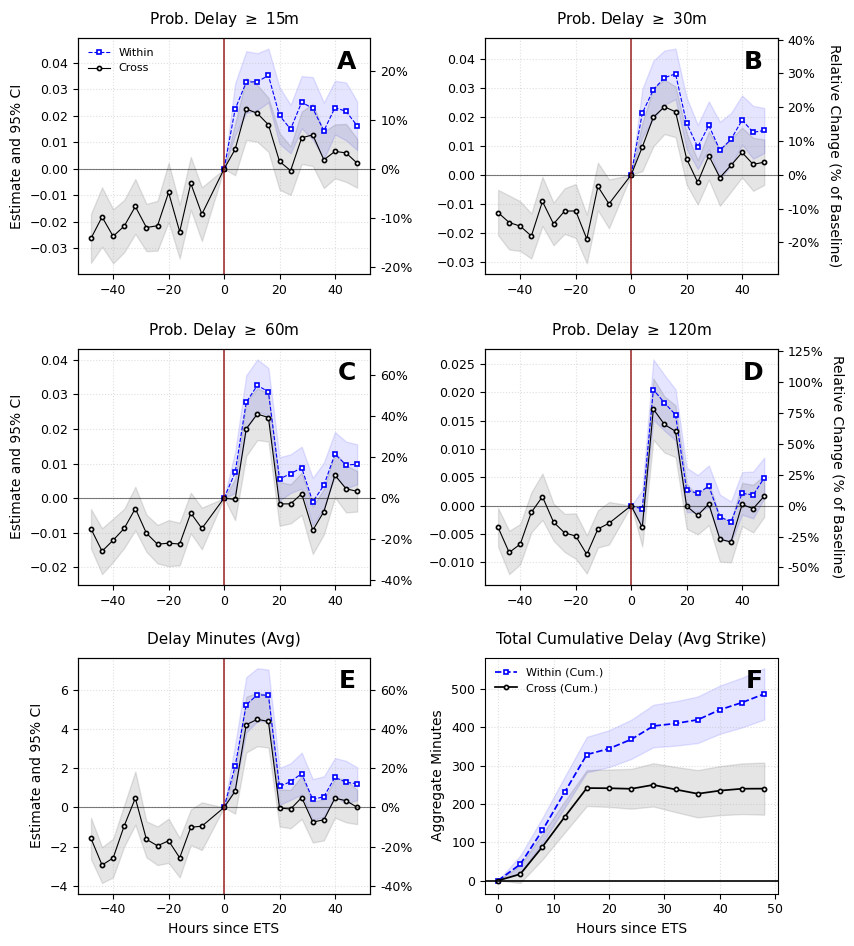

In [13]:
get_full_event_study_results(testing_mode=False, damage=0, arrival_departure='Arrival')

---- 1. ESTIMATING MODELS FOR: Prob. Delay ≥ 15m ----
Running "Within-Airline Estimator" on 140,410 observations...
Running "Cross-Airline Estimator" on 463,125 observations...
Successfully exported stacked results to: results/damaging_arrival_delay_gt_15.csv

---- 2. ESTIMATING MODELS FOR: Prob. Delay ≥ 30m ----
Running "Within-Airline Estimator" on 140,410 observations...
Running "Cross-Airline Estimator" on 463,125 observations...
Successfully exported stacked results to: results/damaging_arrival_delay_gt_30.csv

---- 3. ESTIMATING MODELS FOR: Prob. Delay ≥ 60m ----
Running "Within-Airline Estimator" on 140,410 observations...
Running "Cross-Airline Estimator" on 463,125 observations...
Successfully exported stacked results to: results/damaging_arrival_delay_gt_60.csv

---- 4. ESTIMATING MODELS FOR: Prob. Delay ≥ 120m ----
Running "Within-Airline Estimator" on 140,410 observations...
Running "Cross-Airline Estimator" on 463,125 observations...
Successfully exported stacked results t

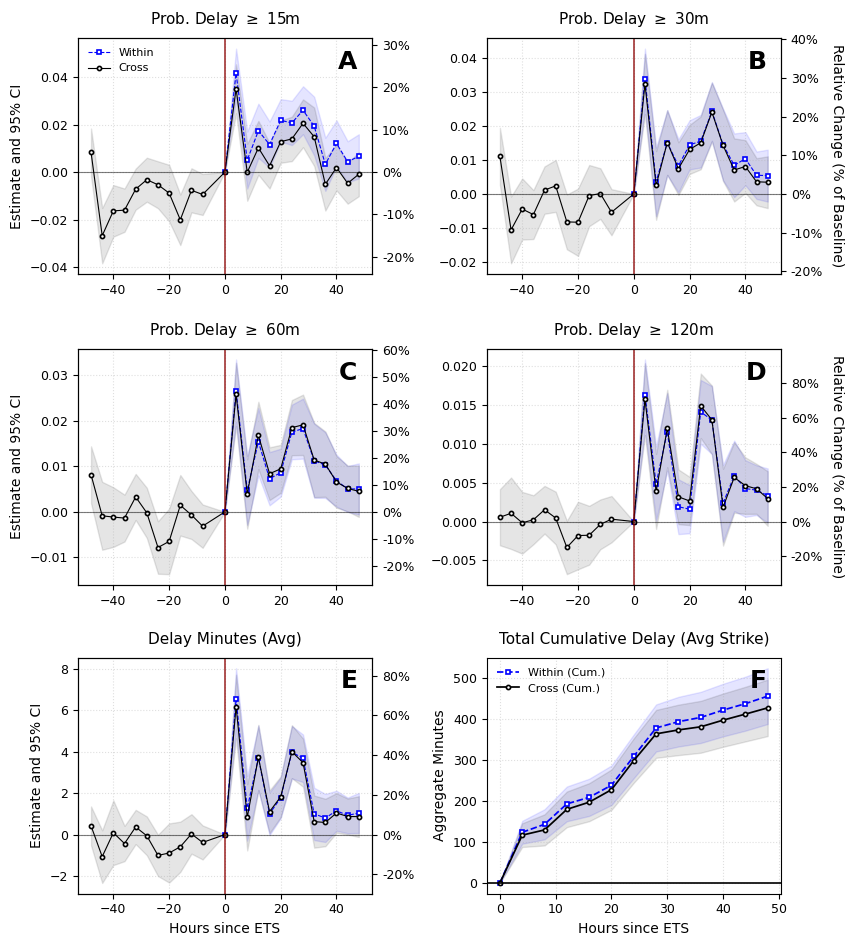

In [14]:
get_full_event_study_results(testing_mode=False, damage=1, arrival_departure='Arrival')

---- 1. ESTIMATING MODELS FOR: Prob. Delay ≥ 15m ----
Running "Within-Airline Estimator" on 187,413 observations...
Running "Cross-Airline Estimator" on 567,414 observations...
Successfully exported stacked results to: results/non_damaging_departure_delay_gt_15.csv

---- 2. ESTIMATING MODELS FOR: Prob. Delay ≥ 30m ----
Running "Within-Airline Estimator" on 187,413 observations...
Running "Cross-Airline Estimator" on 567,414 observations...
Successfully exported stacked results to: results/non_damaging_departure_delay_gt_30.csv

---- 3. ESTIMATING MODELS FOR: Prob. Delay ≥ 60m ----
Running "Within-Airline Estimator" on 187,413 observations...
Running "Cross-Airline Estimator" on 567,414 observations...
Successfully exported stacked results to: results/non_damaging_departure_delay_gt_60.csv

---- 4. ESTIMATING MODELS FOR: Prob. Delay ≥ 120m ----
Running "Within-Airline Estimator" on 187,413 observations...
Running "Cross-Airline Estimator" on 567,414 observations...
Successfully exported

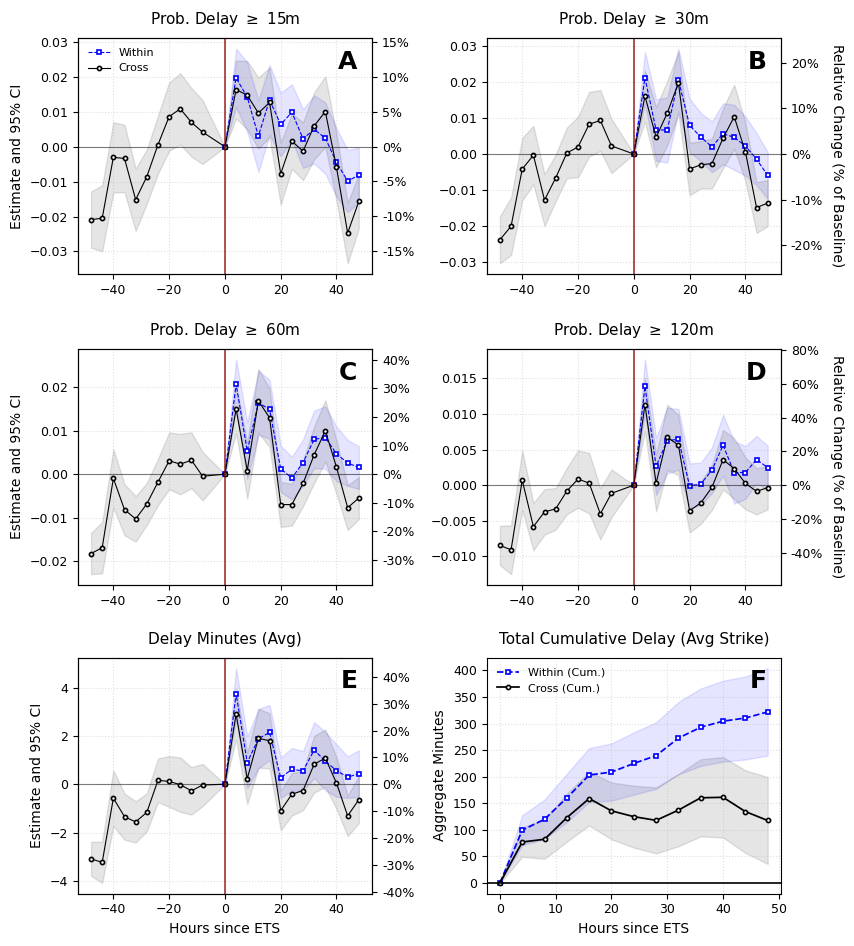

In [15]:
get_full_event_study_results(testing_mode=False, damage=0, arrival_departure='Departure')

---- 1. ESTIMATING MODELS FOR: Prob. Delay ≥ 15m ----
Running "Within-Airline Estimator" on 179,817 observations...
Running "Cross-Airline Estimator" on 564,849 observations...
Successfully exported stacked results to: results/damaging_departure_delay_gt_15.csv

---- 2. ESTIMATING MODELS FOR: Prob. Delay ≥ 30m ----
Running "Within-Airline Estimator" on 179,817 observations...
Running "Cross-Airline Estimator" on 564,849 observations...
Successfully exported stacked results to: results/damaging_departure_delay_gt_30.csv

---- 3. ESTIMATING MODELS FOR: Prob. Delay ≥ 60m ----
Running "Within-Airline Estimator" on 179,817 observations...
Running "Cross-Airline Estimator" on 564,849 observations...
Successfully exported stacked results to: results/damaging_departure_delay_gt_60.csv

---- 4. ESTIMATING MODELS FOR: Prob. Delay ≥ 120m ----
Running "Within-Airline Estimator" on 179,817 observations...
Running "Cross-Airline Estimator" on 564,849 observations...
Successfully exported stacked res

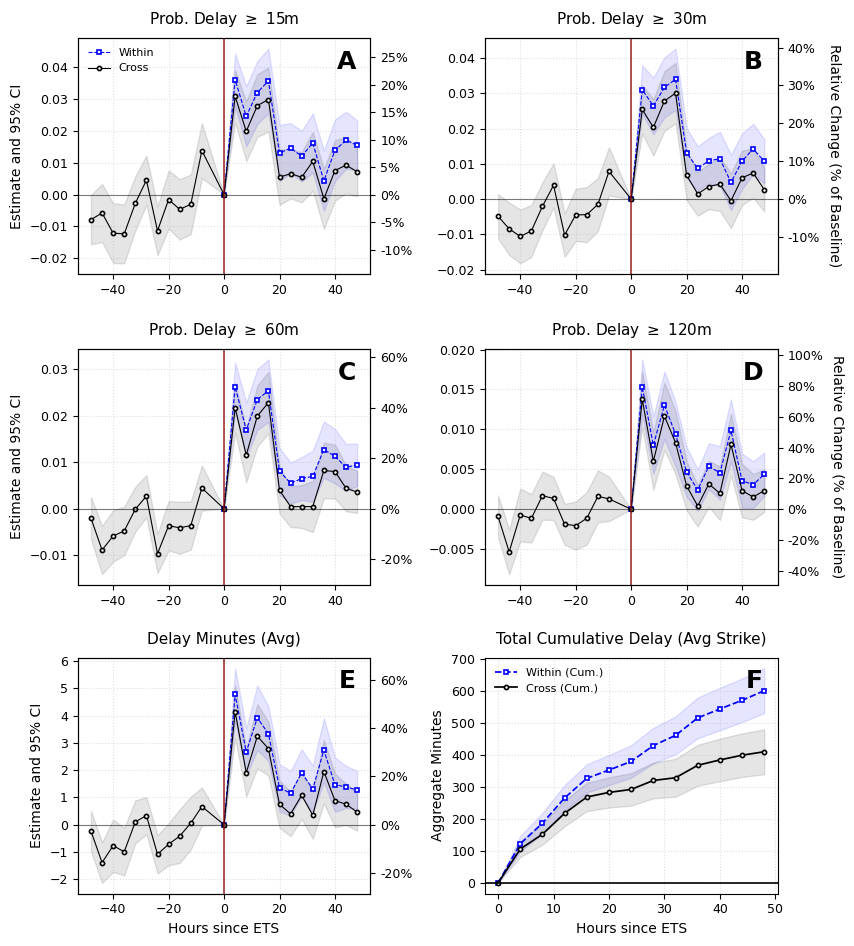

In [16]:
get_full_event_study_results(testing_mode=False, damage=1, arrival_departure='Departure')

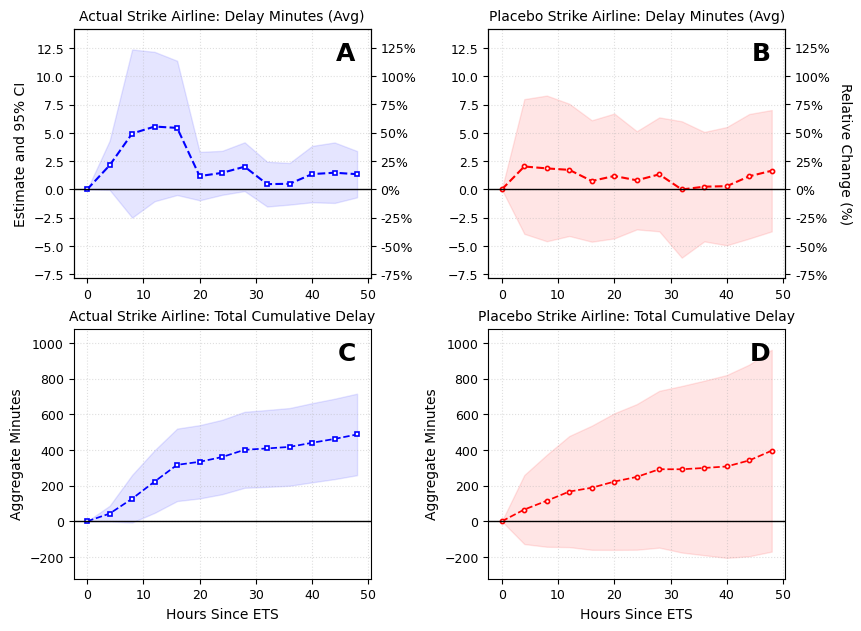

In [35]:
plot_actual_vs_placebo_comparison('bootstrap_results/actual/non_damaging_arrival_departure_delay_minutes.csv', 
                                  'bootstrap_results/placebo/non_damaging_arrival_departure_delay_minutes.csv', 
                                  master_df, damage=0, arrival_departure='Arrival')

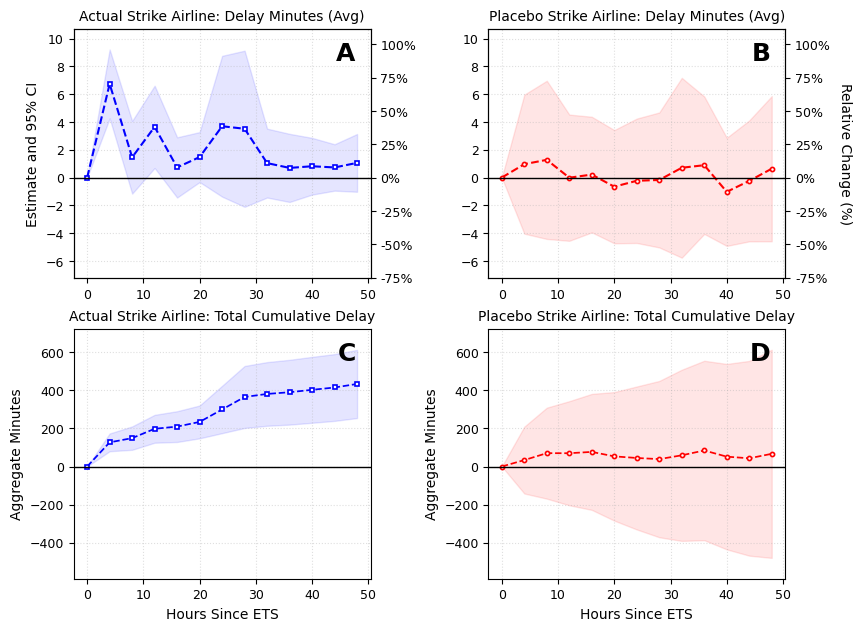

In [36]:
plot_actual_vs_placebo_comparison('bootstrap_results/actual/damaging_arrival_departure_delay_minutes.csv', 
                                  'bootstrap_results/placebo/damaging_arrival_departure_delay_minutes.csv', 
                                  master_df, damage=1, arrival_departure='Arrival')

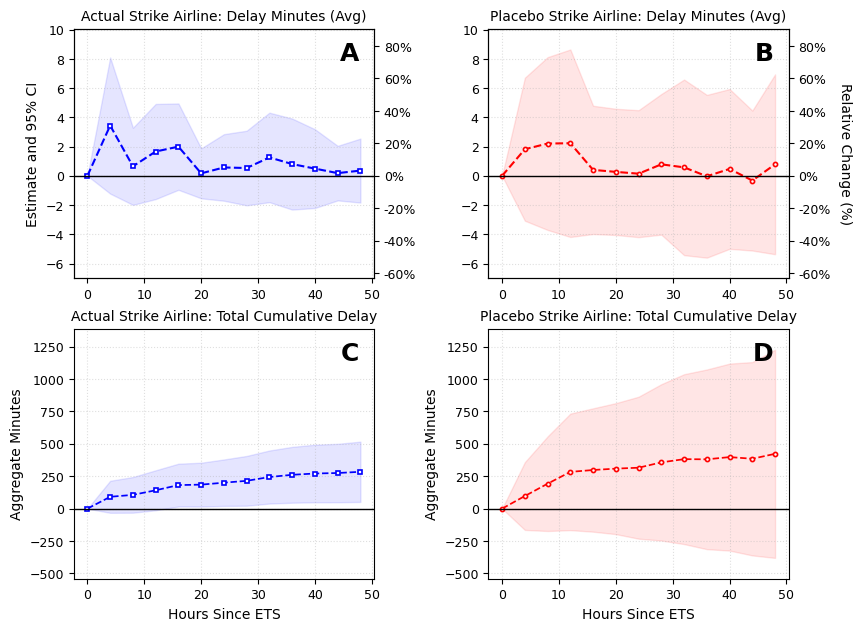

In [37]:
plot_actual_vs_placebo_comparison('bootstrap_results/actual/non_damaging_departure_departure_delay_minutes.csv', 
                                  'bootstrap_results/placebo/non_damaging_departure_departure_delay_minutes.csv', 
                                  master_df, damage=0, arrival_departure='Departure')

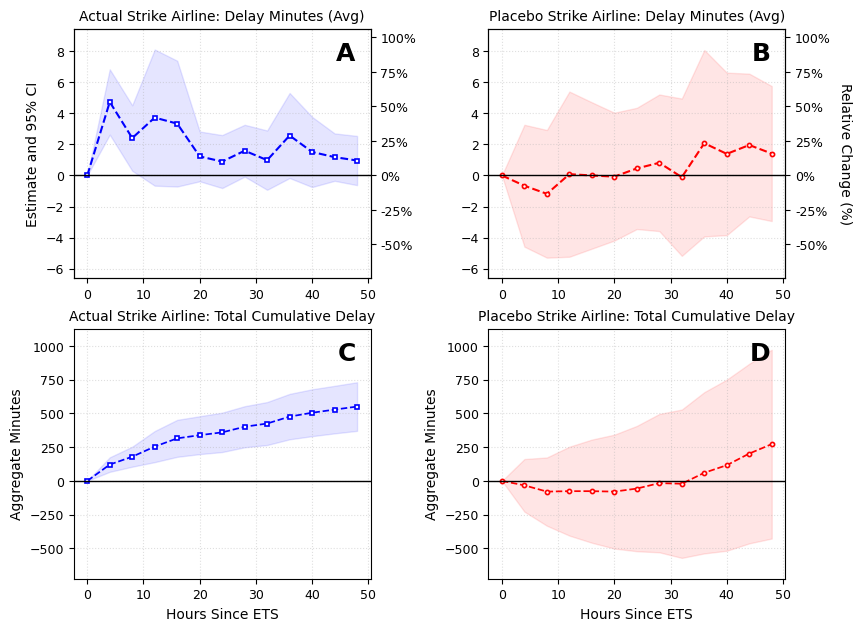

In [38]:
plot_actual_vs_placebo_comparison('bootstrap_results/actual/damaging_departure_departure_delay_minutes.csv', 
                                  'bootstrap_results/placebo/damaging_departure_departure_delay_minutes.csv', 
                                  master_df, damage=1, arrival_departure='Departure')